# Checking effects of hybrid quantile mapping approach.

This notebook tests our implementation of a hybrid quantile mapping approach, and checks how it is different from parametric and nonparametric quantile mapping. This hybrid approach is a combination of parametric and nonparametric quantile mapping. It does nonparametric quantile mapping most of the time, but uses parametric quantile mapping when a detrended value is outside the range of the modeled historical (which is what is used to construct the mapping between the model and observations). Because the modeled future scenario is detrended, this doesn't happen that often, but it does happen sometimes.

# 0. Set up workspace

In [1]:
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

from saidownscale.bcsd_config import BCSDConfig, PipelineOptions
from saidownscale.pipeline import BCSDPipeline

# 1. Define Configuration

we'll configure a BCSD run for:
- GCM: CESM2-WACCM
- Variable: tas (temperature)
- Scenario: SSP245
- Region: South Africa
- Environment: qa (for testing)

In [2]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'South Africa'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
bounds = [round(entry, 2) for entry in bounds]

print(f"South Africa subset bounds: {bounds}")

South Africa subset bounds: [np.float64(-48.96), np.float64(-20.15), np.float64(14.45), np.float64(39.89)]


# 2. Run pipeline for three different quantile mapping approaches
(a) nonparametric, (b) parametric, and (c) hybrid

### 2a. Nonparametric quantile mapping

In [3]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    debias_approach="nonparametric",
)

# Operational settings (storage paths, environment, runtime flags).
# These live in PipelineOptions and do not affect the computation or cache key.
options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    branch="v5.6_nonparametric",
    verbose=True,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.variable_config.detrend_data}")

Run ID: CESM2-WACCM_tas_r1i1p1f1_SSP245_subset
Config hash: 3a1839139748
Detrend data: True


In [4]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_nonparametric = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_nonparametric}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_nonparametric = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_nonparametric}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_nonparametric = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_nonparametric}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


### 2b. Parametric quantile mapping

In [5]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    debias_approach="parametric",
)

# Operational settings (storage paths, environment, runtime flags).
# These live in PipelineOptions and do not affect the computation or cache key.
options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    branch="v5.6_parametric",
    verbose=True,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.variable_config.detrend_data}")

Run ID: CESM2-WACCM_tas_r1i1p1f1_SSP245_subset
Config hash: 3a75acbedb6d
Detrend data: True


In [6]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_parametric = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_parametric}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_parametric = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_parametric}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_parametric = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_parametric}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_parametric/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_parametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


### 2c. Hybrid nonparametric/parametric quantile mapping

In [7]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    debias_approach="nonparametric_hybrid",
)

# Operational settings (storage paths, environment, runtime flags).
# These live in PipelineOptions and do not affect the computation or cache key.
options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    branch="v5.6_nonparametric_hybrid",
    verbose=True,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.variable_config.detrend_data}")

Run ID: CESM2-WACCM_tas_r1i1p1f1_SSP245_subset
Config hash: 5449d055dc96
Detrend data: True


In [8]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_hybrid = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_hybrid}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_hybrid = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_hybrid}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_hybrid = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_hybrid}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric_hybrid/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


# 3. Load data for analyzing differences between these approaches

In [9]:
# import icechunk
bucket = "carbonplan-scratch"
prefix_nonparametric = "srm/bcsd-cache/qa/6_nonparametric_hybrid/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk"


def open_icechunk(path, prefix=prefix_nonparametric):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [10]:
bucket, prefix = obs_path_nonparametric.replace("s3://", "").split("/", 1)
bucket, prefix

('carbonplan-scratch',
 'srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk')

In [11]:
# Load cached artifacts
obs_coarse_nonparametric = open_icechunk(obs_path_nonparametric, prefix=prefix_nonparametric)[
    config.variable
]
historical_downscaled_nonparametric = open_icechunk(
    hist_path_nonparametric, prefix=prefix_nonparametric
)[config.variable]
scenario_downscaled_nonparametric = open_icechunk(
    scenario_path_nonparametric, prefix=prefix_nonparametric
)[config.variable]

obs_coarse_parametric = open_icechunk(obs_path_parametric)[config.variable]
historical_downscaled_parametric = open_icechunk(hist_path_parametric)[config.variable]
scenario_downscaled_parametric = open_icechunk(scenario_path_parametric)[config.variable]

obs_coarse_hybrid = open_icechunk(obs_path_hybrid)[config.variable]
historical_downscaled_hybrid = open_icechunk(hist_path_hybrid)[config.variable]
scenario_downscaled_hybrid = open_icechunk(scenario_path_hybrid)[config.variable]

In [12]:
detrended_scenario_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.5_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_detrended.icechunk"
detrended_scenario = open_icechunk(detrended_scenario_path)[config.variable]

In [13]:
debiased_scenario_coarse_nonparametric_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_coarse.icechunk"
debiased_scenario_coarse_nonparametric = open_icechunk(debiased_scenario_coarse_nonparametric_path)[
    config.variable
]

debiased_scenario_coarse_hybrid_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_coarse.icechunk"
debiased_scenario_coarse_hybrid = open_icechunk(debiased_scenario_coarse_hybrid_path)[
    config.variable
]

In [14]:
# Also load the raw GCM data for comparison
from saidownscale.downscaling_utils import get_experiment, get_obs, subset_space

# Load fine-resolution observations
obs_fine = get_obs(var=config.variable)
obs_fine = subset_space(obs_fine, bounds)
obs_fine = obs_fine.sel(time=slice("1978", "2014"))

# Load coarse GCM data
model_hist_raw = get_experiment(gcm=config.gcm, scenario="Historical", var=config.variable)
if "ensemble_member" in model_hist_raw.dims:
    model_hist_raw = model_hist_raw.sel(ensemble_member=config.ensemble_member)
model_hist_raw = subset_space(model_hist_raw, bounds)
model_hist_raw = model_hist_raw.sel(time=slice("1978", "2014"))

model_scenario_raw = get_experiment(gcm=config.gcm, scenario=config.scenario, var=config.variable)
model_scenario_raw = model_scenario_raw.sel(ensemble_member=config.ensemble_member)
model_scenario_raw = subset_space(model_scenario_raw, bounds)
model_scenario_raw = model_scenario_raw.sel(time=slice("2015", "2100"))

print("Loaded raw GCM data for comparison")

Loaded raw GCM data for comparison


# 4. Compare approaches

### 4a. How often is hybrid different from nonparametric?
i.e. How often is the detrended future outside the bounds of the modeled historical?

The plot below shows how different the hybrid and nonparametric approaches are *after* debiasing but *before* spatial disaggregation

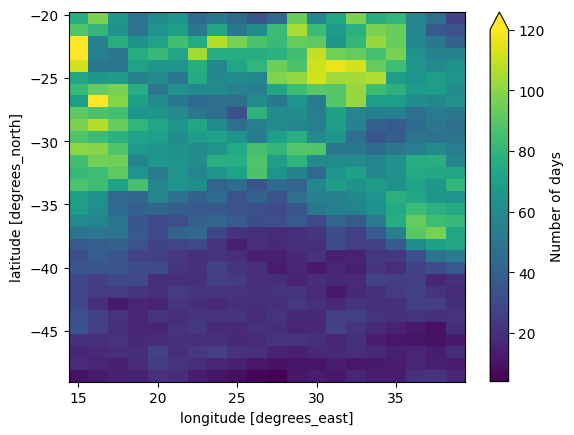

In [15]:
p = (
    (debiased_scenario_coarse_hybrid != debiased_scenario_coarse_nonparametric)
    .sum(dim="time")
    .plot(
        vmax=120,
    )
)
p.colorbar.set_label("Number of days")

The plot below shows how different the hybrid and nonparametric approaches are in the final results. I.e., after both debiasing and spatial disaggregation

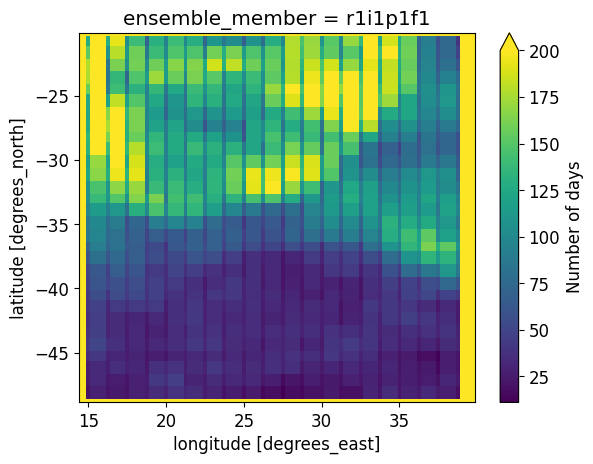

In [32]:
p = (scenario_downscaled_hybrid != scenario_downscaled_nonparametric).sum(dim="time").plot(vmax=200)
p.colorbar.set_label("Number of days")

What is going on at the edges?

In [30]:
(~scenario_downscaled_hybrid[:, 0, 0].isnull()).sum().values

array(0)

In [31]:
(~scenario_downscaled_nonparametric[:, 0, 0].isnull()).sum().values

array(0)

### 4b. Visualize difference between approaches at Cape Town, specifically

In [19]:
# Get Cape Town coordinates
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_lon = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item())
cape_town_lat = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item())

print(f"Cape Town: ({cape_town_lat:.2f}°, {cape_town_lon:.2f}°)")

Cape Town: (-33.92°, 18.43°)


In [20]:
# Extract Cape Town data
obs_fine_ct = obs_fine.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()
model_hist_raw_ct = model_hist_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
model_scenario_raw_ct = model_scenario_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

obs_coarse_ct_parametric = obs_coarse_parametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct_parametric = historical_downscaled_parametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct_parametric = scenario_downscaled_parametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

obs_coarse_ct_nonparametric = obs_coarse_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct_nonparametric = historical_downscaled_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct_nonparametric = scenario_downscaled_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

obs_coarse_ct_hybrid = obs_coarse_hybrid.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct_hybrid = historical_downscaled_hybrid.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct_hybrid = scenario_downscaled_hybrid.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

print("✓ Extracted Cape Town time series")

✓ Extracted Cape Town time series


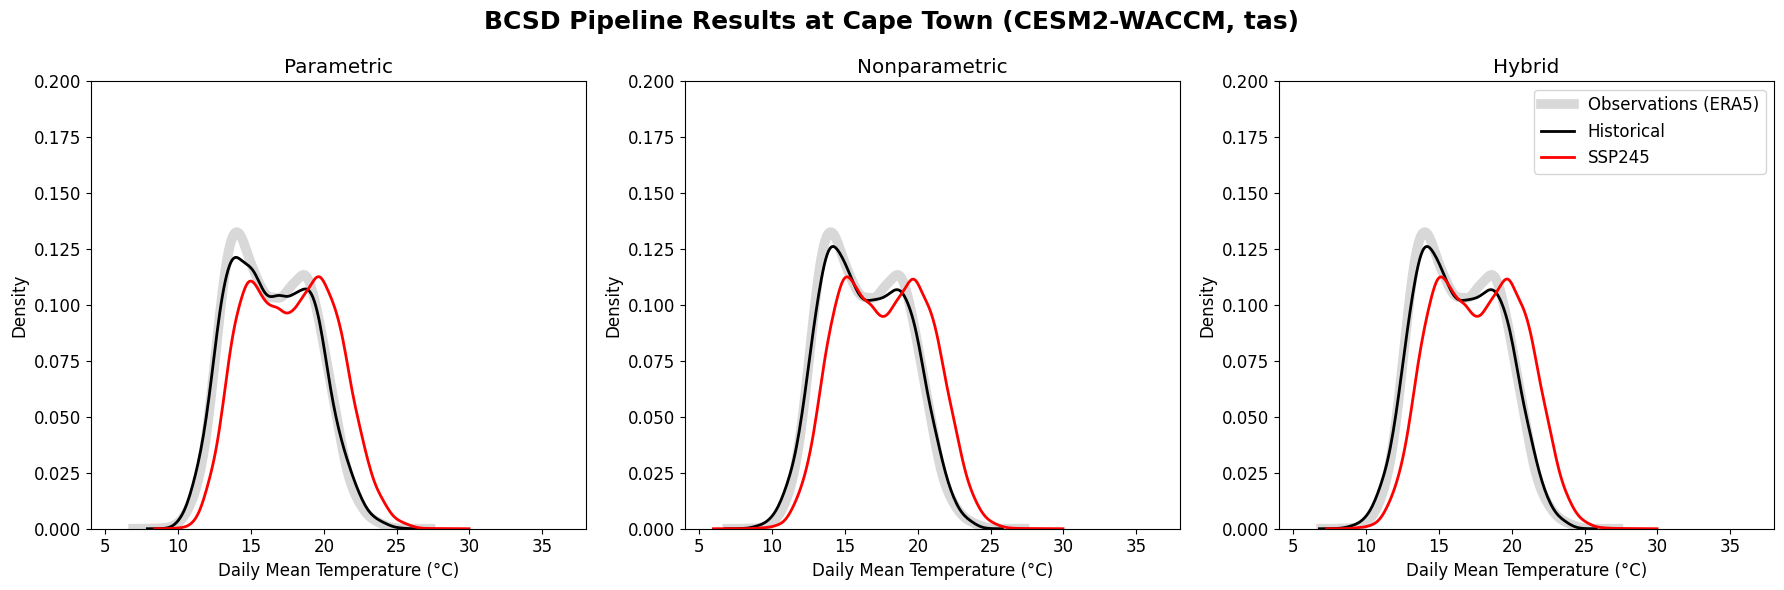

In [21]:
# Note: For the debiased coarse data, we need to compute it since pipeline doesn't cache it
# In production, we might want to cache the intermediate debiased-but-not-downscaled data

# Create figure
plt.rcParams["font.size"] = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["black", "red"]
labels = ["Historical", "SSP245"]


def format_subplot(ax, res="coarse"):
    """Add observation distribution to subplot"""
    if res == "coarse":
        sns.kdeplot(
            obs_coarse_ct_parametric.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    elif res == "fine":
        sns.kdeplot(
            obs_fine_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    ax.set_ylim([0, 0.2])
    ax.set_xlim([4, 38])
    ax.set_xlabel("Daily Mean Temperature (°C)")


# Panel 1: Raw model output
ax = axes[0]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct_parametric.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct_parametric.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Parametric")

ax = axes[1]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct_nonparametric.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct_nonparametric.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Nonparametric")

ax = axes[2]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct_hybrid.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct_hybrid.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Hybrid")

plt.suptitle(
    f"BCSD Pipeline Results at Cape Town ({config.gcm}, {config.variable})",
    fontsize=18,
    fontweight="bold",
)

axes[2].legend(fontsize=12)
plt.tight_layout()
plt.show()

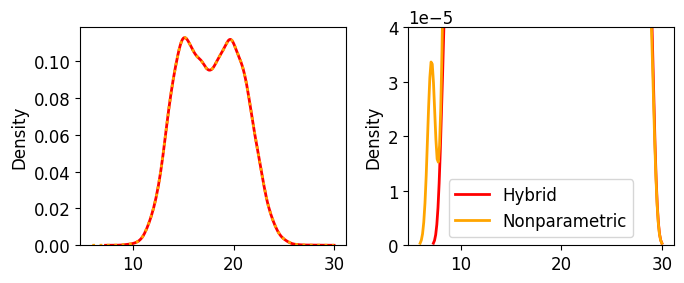

In [22]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
sns.kdeplot(
    scenario_downscaled_ct_hybrid.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
)
sns.kdeplot(
    scenario_downscaled_ct_nonparametric.values - 273.15,
    label=labels[1],
    color="orange",
    linestyle=":",
    linewidth=2,
)
plt.subplot(1, 2, 2)
sns.kdeplot(
    scenario_downscaled_ct_hybrid.values - 273.15,
    label="Hybrid",
    color=colors[1],
    linewidth=2,
)
sns.kdeplot(
    scenario_downscaled_ct_nonparametric.values - 273.15,
    label="Nonparametric",
    color="orange",
    linestyle="-",
    linewidth=2,
)
plt.legend()
plt.ylim([0, 0.00004])
plt.tight_layout()

Text(0, 0.5, 'Hybrid downscaled values')

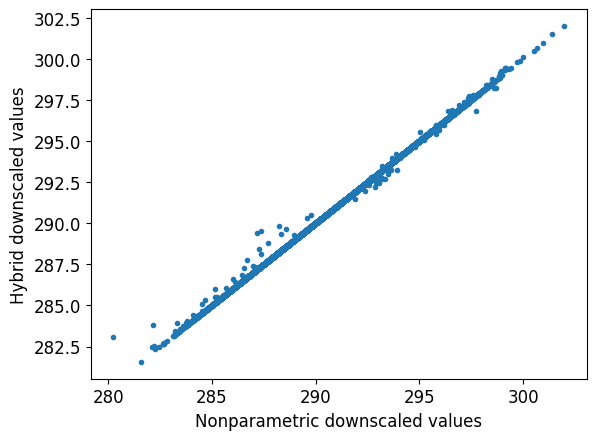

In [23]:
plt.plot(
    scenario_downscaled_ct_nonparametric,
    scenario_downscaled_ct_hybrid,
    ".",
)
plt.xlabel("Nonparametric downscaled values")
plt.ylabel("Hybrid downscaled values")

### 4c. Check that the following are identical:
* obs_coarse for all quantile mapping approaches (quantile mapping should not affect that step at all)
* historical downscaled results are the same for nonparametric and hybrid (hybrid should only affect the future, not the historical)

In [24]:
import numpy as np

print(np.nanmax(obs_coarse_hybrid - obs_coarse_nonparametric))
print(np.nanmin(obs_coarse_hybrid - obs_coarse_nonparametric))

print(np.nanmax(obs_coarse_hybrid - obs_coarse_parametric))
print(np.nanmin(obs_coarse_hybrid - obs_coarse_parametric))

print(np.nanmax(historical_downscaled_nonparametric - historical_downscaled_hybrid))
print(np.nanmin(historical_downscaled_nonparametric - historical_downscaled_hybrid))

0.0
0.0
0.0
0.0
0.0
0.0


### 4d. Examine spatial pattern of differences between nonparametric and hybrid

Spatial pattern of mean differences between two approaches

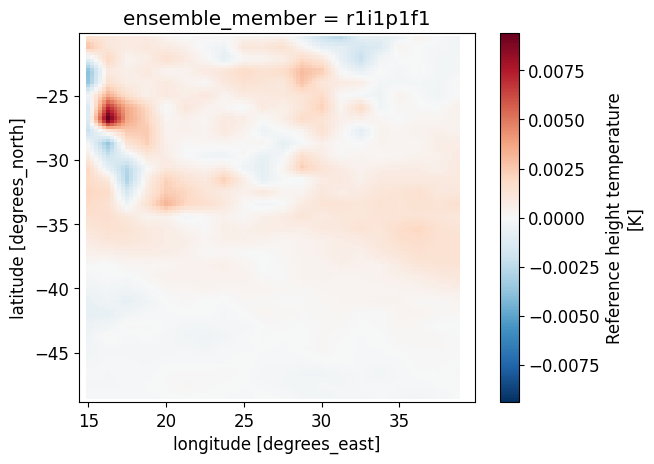

In [25]:
(scenario_downscaled_hybrid - scenario_downscaled_nonparametric).mean(dim="time").plot()

Spatial pattern of extreme differences between two approaches (1st percentile and 99th percentile)

In [26]:
hot_extreme_delta_map = (scenario_downscaled_hybrid).quantile(0.99, dim="time") - (
    scenario_downscaled_nonparametric
).quantile(0.99, dim="time")

In [27]:
cold_extreme_delta_map = (scenario_downscaled_hybrid).quantile(0.01, dim="time") - (
    scenario_downscaled_nonparametric
).quantile(0.01, dim="time")

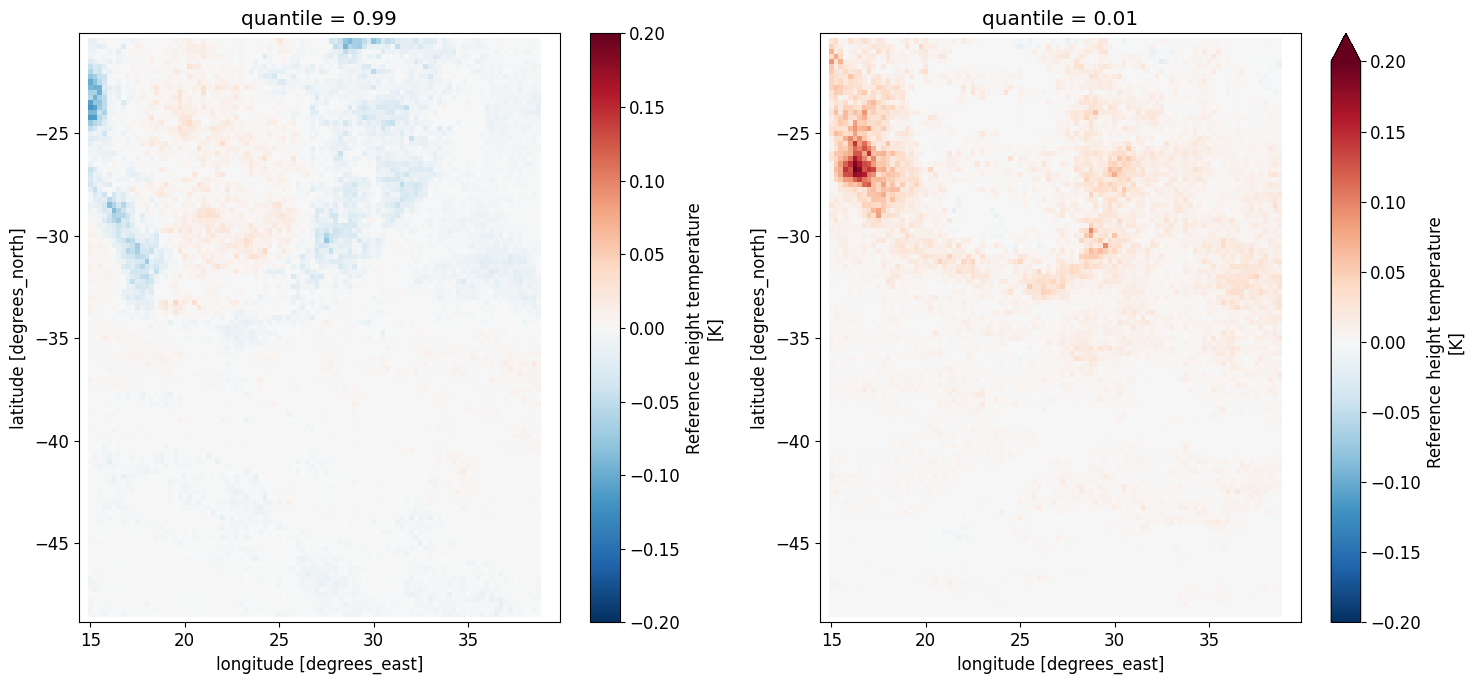

In [28]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
hot_extreme_delta_map.plot(vmax=0.2)
plt.subplot(1, 2, 2)
cold_extreme_delta_map.plot(vmax=0.2)
plt.tight_layout()